In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
import numpy as np
df=pd.read_csv("LensesNewDataset.csv")

In [2]:
df.head()

,Age,Spectacle_Prescription,Astigmatic,Tear_Production,Lenses
0,Young,Myope,No,Reduced,No Contact Lenses
1,Young,Myope,No,Normal,Soft Contact Lenses
2,Young,Myope,Yes,Reduced,No Contact Lenses
3,Young,Myope,Yes,Normal,Hard Contact Lenses
4,Young,Hypermetrope,No,Reduced,No Contact Lenses


In [3]:
# Rule: If tear production is reduced, they can now wear Scleral lenses
df.loc[df['Tear_Production'] == 'Reduced', 'Lenses'] = 'Scleral Lenses'

# Rule: If they have astigmatism but normal tears, they get Soft Toric instead of Hard
df.loc[(df['Astigmatic'] == 'Yes') & (df['Tear_Production'] == 'Normal'), 'Lenses'] = 'Soft Toric'

# Rule: If they are Presbyopic, they get Multifocals
df.loc[df['Age'] == 'Presbyopic', 'Lenses'] = 'Multifocal'

In [4]:
df.head()

,Age,Spectacle_Prescription,Astigmatic,Tear_Production,Lenses
0,Young,Myope,No,Reduced,Scleral Lenses
1,Young,Myope,No,Normal,Soft Contact Lenses
2,Young,Myope,Yes,Reduced,Scleral Lenses
3,Young,Myope,Yes,Normal,Soft Toric
4,Young,Hypermetrope,No,Reduced,Scleral Lenses


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     24 non-null     object
 1   Spectacle_Prescription  24 non-null     object
 2   Astigmatic              24 non-null     object
 3   Tear_Production         24 non-null     object
 4   Lenses                  24 non-null     object
dtypes: object(5)
memory usage: 1.1+ KB


In [6]:
df.shape

(24, 5)

In [7]:
df.describe()

,Age,Spectacle_Prescription,Astigmatic,Tear_Production,Lenses
count,24,24,24,24,24
unique,3,2,2,2,4
top,Young,Myope,No,Reduced,Scleral Lenses
freq,8,12,12,12,8


In [8]:
print(df.isnull().sum())

Age                       0
Spectacle_Prescription    0
Astigmatic                0
Tear_Production           0
Lenses                    0
dtype: int64


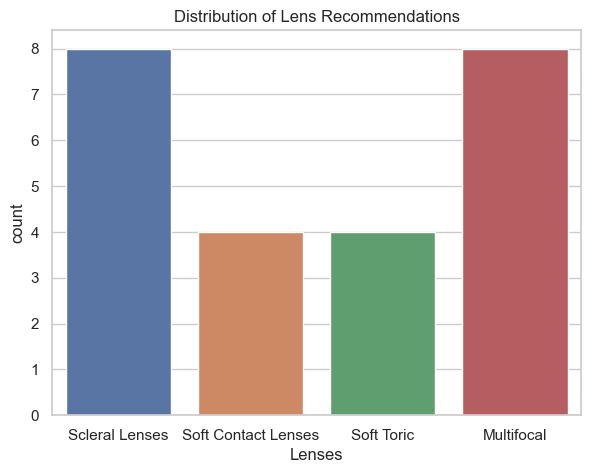

In [19]:
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Plot 1: Target Class Distribution (The 'Lenses' column)
plt.subplot(1, 2, 1)
sns.countplot(x='Lenses', data=df,  hue='Lenses',legend=False)
plt.title('Distribution of Lens Recommendations')
plt.show()

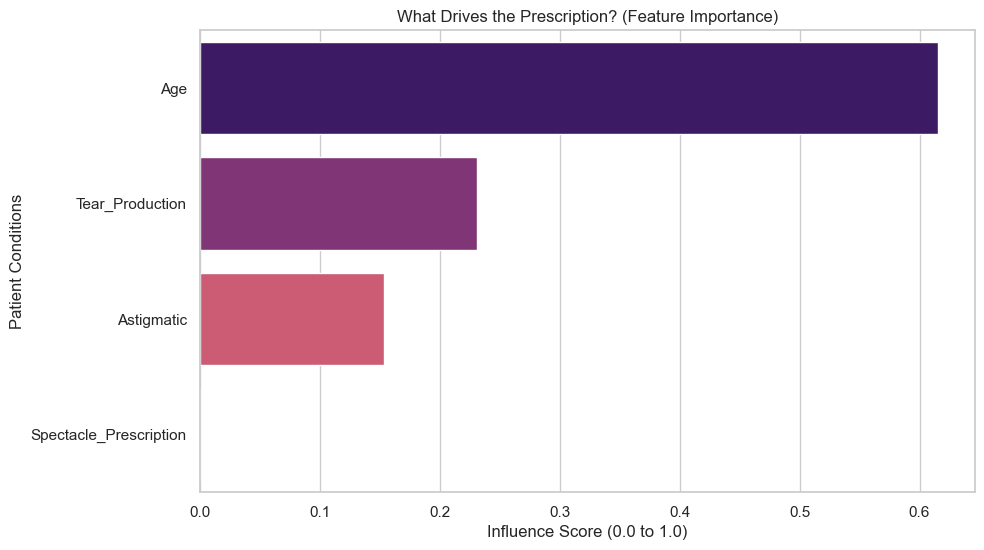

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importances
importances = model.feature_importances_
feature_names = x.columns

# 2. Create a sorted Series for plotting
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 3. Plot the Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances.values, y=feat_importances.index, hue=feat_importances.index, palette='magma', legend=False)

plt.title('What Drives the Prescription? (Feature Importance)')
plt.xlabel('Influence Score (0.0 to 1.0)')
plt.ylabel('Patient Conditions')
plt.show()

In [10]:
le = LabelEncoder()
df_encoded = df.copy()
for col in df.columns:
    df_encoded[col]=le.fit_transform(df[col])
    
df_encoded

,Age,Spectacle_Prescription,Astigmatic,Tear_Production,Lenses
0,2,1,0,1,1
1,2,1,0,0,2
2,2,1,1,1,1
3,2,1,1,0,3
4,2,0,0,1,1
5,2,0,0,0,2
6,2,0,1,1,1
7,2,0,1,0,3
8,0,1,0,1,1
9,0,1,0,0,2


In [11]:
x = df_encoded.drop('Lenses', axis=1) # Features
y = df_encoded['Lenses']              # Target

In [12]:
model = DecisionTreeClassifier()
model.fit(x, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [14]:
y_pred = model.predict(x)
y_pred

array([1, 2, 1, 3, 1, 2, 1, 3, 1, 2, 1, 3, 1, 2, 1, 3, 0, 0, 0, 0, 0, 0,
       0, 0])

In [15]:
# Print Performance Summary
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("--- Model Performance Summary ---")
print(f"Accuracy: {accuracy_score(y, y_pred) * 100}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

print("\nDetailed Classification Report:")
print(classification_report(y, y_pred, target_names=le.classes_))

--- Model Performance Summary ---
Accuracy: 100.0%

Confusion Matrix:
[[8 0 0 0]
 [0 8 0 0]
 [0 0 4 0]
 [0 0 0 4]]

Detailed Classification Report:
                     precision    recall  f1-score   support

         Multifocal       1.00      1.00      1.00         8
     Scleral Lenses       1.00      1.00      1.00         8
Soft Contact Lenses       1.00      1.00      1.00         4
         Soft Toric       1.00      1.00      1.00         4

           accuracy                           1.00        24
          macro avg       1.00      1.00      1.00        24
       weighted avg       1.00      1.00      1.00        24



In [16]:
import pickle
with open('Lenses2Prediction.pkl','wb') as f:
    pickle.dump(model,f)
print('model saved')

model saved


In [17]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Multifocal': np.int64(0), 'Scleral Lenses': np.int64(1), 'Soft Contact Lenses': np.int64(2), 'Soft Toric': np.int64(3)}


In [18]:
with open('LensesPrediction.pkl','rb') as f:
    loaded_model=pickle.load(f)
print('model loaded')

model loaded
